In [1]:
import torch
 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
import pandas as pd
#from ctgan import CTGAN

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

In [3]:
df = pd.read_csv("../data/raw/train_clean.csv")

df = df.drop(columns=["Type_of_Loan"])

In [4]:
# create metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)


In [5]:
df_good = df[df["Credit_Score"] == "Good"]
df_standard = df[df["Credit_Score"] == "Standard"]
df_poor = df[df["Credit_Score"] == "Poor"]

In [6]:
# create model
model_good = CTGANSynthesizer(
    metadata,
    epochs=1000,
    cuda=True,
    verbose=True
)

model_poor = CTGANSynthesizer(
    metadata,
    epochs=50,
    cuda=True,
    verbose=True
)


/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/home/sproutmain/deepLearningClass/enviormentForEverythingIThinkIHope/tf_env/lib/python3.10/site-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


In [7]:
model_good.fit(df_good)
#model_poor.fit(df_poor)

Gen. (-01.18) | Discrim. (-00.09): 100%|████████████████████████████████████████████| 1000/1000 [25:49<00:00,  1.55s/it]


In [8]:
target_size = len(df_standard)

n_good_needed = target_size - len(df_good)
n_poor_needed = target_size - len(df_poor)

print(n_good_needed, n_poor_needed)

32679 21886


In [9]:
synthetic_good = model_good.sample(n_good_needed)
#synthetic_poor = model_poor.sample(n_poor_needed)

In [10]:
df_balanced = pd.concat([
    df,
    synthetic_good
    #,synthetic_poor
])

print(df_balanced["Credit_Score"].value_counts())

Credit_Score
Good        48253
Standard    48253
Poor        26367
Name: count, dtype: int64


## check

In [11]:
print(synthetic_good.head())
#print(synthetic_poor.head())

    Age     Occupation  Annual_Income  Monthly_Inhand_Salary  \
0  22.0         Doctor   28873.003346            1700.677729   
1  37.0         Doctor   27507.753527            2768.854328   
2  18.0  Media_Manager   57120.216308            4967.626329   
3  50.0     Journalist   89219.859733            4283.608475   
4  36.0      Developer   59783.034185            4093.706631   

   Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
0                  1                1            5.0          2.0   
1                  7                9           34.0          7.0   
2                  7                3           12.0          4.0   
3                  6                5            8.0          1.0   
4                  6                3           11.0          4.0   

   Delay_from_due_date  Num_of_Delayed_Payment  ...  Credit_Mix  \
0                    4                    10.0  ...        Good   
1                   43                    19.0  ...         Bad   

In [12]:
real = df_good  # or df_poor
synthetic = synthetic_good

print(real.describe())
print(synthetic.describe())

                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  15574.000000   15574.000000           15574.000000       15574.000000   
mean      36.379479   59741.763694            4949.642145           3.471427   
std       11.095029   38736.043350            3217.398529           2.234715   
min       14.000000    7189.540000             332.128333           0.000000   
25%       27.000000   28941.240000            2358.141667           2.000000   
50%       36.000000   43419.770000            3640.177500           3.000000   
75%       46.000000   88596.465000            7333.876667           5.000000   
max       56.000000  149168.880000           12586.480000          10.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     15574.000000   15574.000000  15574.000000         15574.000000   
mean          4.151984       7.717606      2.213561            11.121998   
std           1.820128       4.915690      1.661213

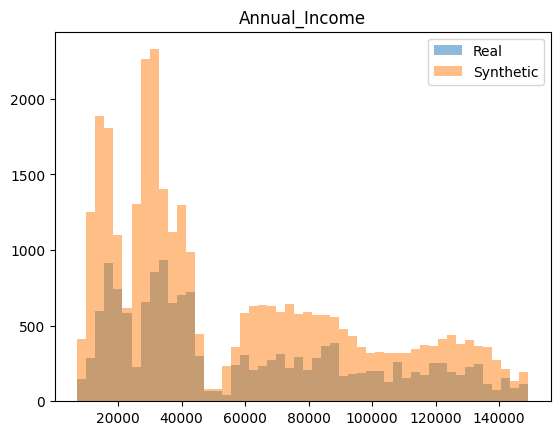

In [13]:
import matplotlib.pyplot as plt

col = "Annual_Income"

plt.hist(real[col], bins=50, alpha=0.5, label="Real")
plt.hist(synthetic[col], bins=50, alpha=0.5, label="Synthetic")
plt.legend()
plt.title(col)
plt.show()

In [14]:
print(real["Credit_Mix"].value_counts(normalize=True))
print(synthetic["Credit_Mix"].value_counts(normalize=True))

Credit_Mix
Good        0.823552
Standard    0.156415
Bad         0.020033
Name: proportion, dtype: float64
Credit_Mix
Good        0.720034
Standard    0.201842
Bad         0.078124
Name: proportion, dtype: float64


In [15]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=df_good,
    synthetic_data=synthetic_good,
    metadata=metadata
)

print(quality_report)

Generating report ...

(1/2) Evaluating Column Shapes: |█████████████████████████████████████████████████████| 22/22 [00:00<00:00, 101.24it/s]|
Column Shapes Score: 89.42%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████| 231/231 [00:01<00:00, 154.00it/s]|
Column Pair Trends Score: 82.98%

Overall Score (Average): 86.2%



In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_datasets(real, synthetic, columns):
    
    numerical_cols = real[columns].select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = real[columns].select_dtypes(include=['object']).columns

    print("\n==============================")
    print("NUMERICAL COLUMN ANALYSIS")
    print("=====================================================")


    for col in numerical_cols:
        print(f"\n--- {col} ---")
        
        # Stats
        real_mean = real[col].mean()
        synth_mean = synthetic[col].mean()
        real_std = real[col].std()
        synth_std = synthetic[col].std()

        print(f"Real Mean: {real_mean:.2f} | Synthetic Mean: {synth_mean:.2f}")
        print(f"Real Std:  {real_std:.2f} | Synthetic Std:  {synth_std:.2f}")

        # Plot
        plt.figure()
        plt.hist(real[col].dropna(), bins=50, alpha=0.5, label="Real")
        plt.hist(synthetic[col].dropna(), bins=50, alpha=0.5, label="Synthetic")
        plt.legend()
        plt.title(col)
        plt.show()

    print("\n==============================")
    print("CATEGORICAL COLUMN ANALYSIS")
    print("=====================================================")


    for col in categorical_cols:
        print(f"\n--- {col} ---")

        real_counts = real[col].value_counts(normalize=True)
        synth_counts = synthetic[col].value_counts(normalize=True)

        comparison = pd.DataFrame({
            "Real": real_counts,
            "Synthetic": synth_counts
        }).fillna(0)

        print(comparison)

        # Plot
        comparison.plot(kind='bar')
        plt.title(col)
        plt.show()


NUMERICAL COLUMN ANALYSIS

--- Age ---
Real Mean: 36.38 | Synthetic Mean: 34.25
Real Std:  11.10 | Synthetic Std:  10.53


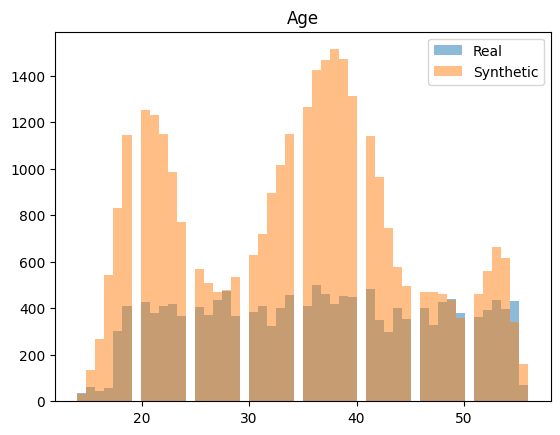


--- Annual_Income ---
Real Mean: 59741.76 | Synthetic Mean: 56470.34
Real Std:  38736.04 | Synthetic Std:  38537.68


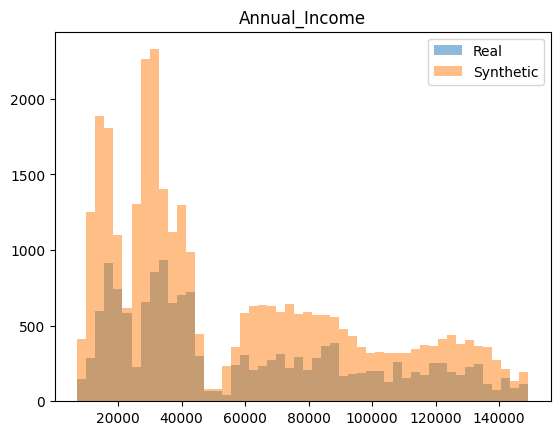


--- Monthly_Inhand_Salary ---
Real Mean: 4949.64 | Synthetic Mean: 4715.33
Real Std:  3217.40 | Synthetic Std:  3131.22


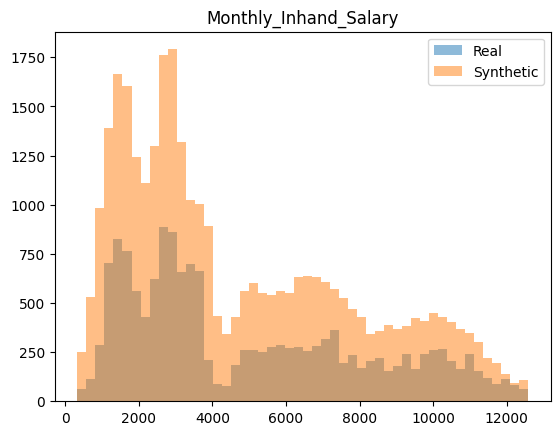


--- Num_Bank_Accounts ---
Real Mean: 3.47 | Synthetic Mean: 4.12
Real Std:  2.23 | Synthetic Std:  2.20


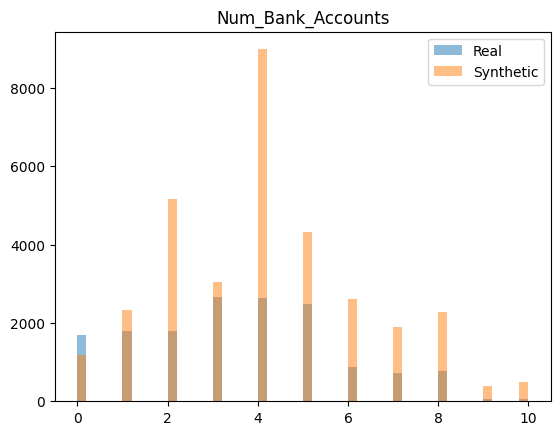


--- Num_Credit_Card ---
Real Mean: 4.15 | Synthetic Mean: 4.55
Real Std:  1.82 | Synthetic Std:  1.89


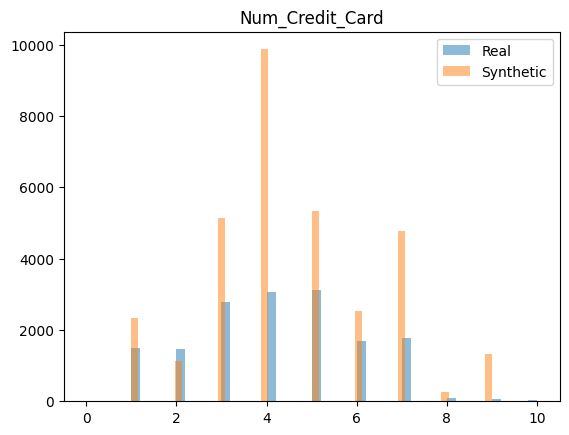


--- Interest_Rate ---
Real Mean: 7.72 | Synthetic Mean: 10.37
Real Std:  4.92 | Synthetic Std:  6.55


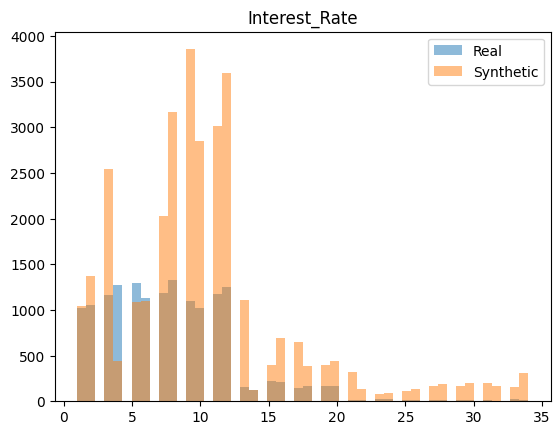


--- Num_of_Loan ---
Real Mean: 2.21 | Synthetic Mean: 2.61
Real Std:  1.66 | Synthetic Std:  2.13


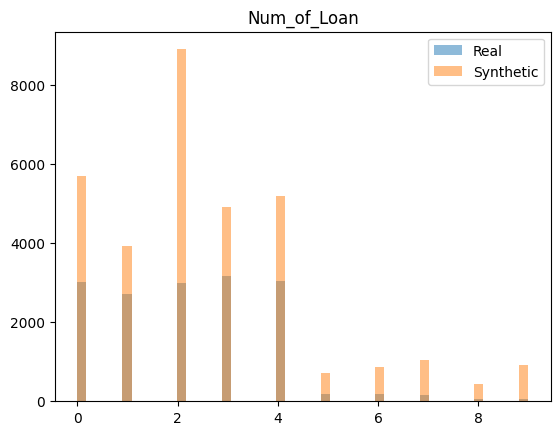


--- Delay_from_due_date ---
Real Mean: 11.12 | Synthetic Mean: 13.06
Real Std:  8.47 | Synthetic Std:  10.73


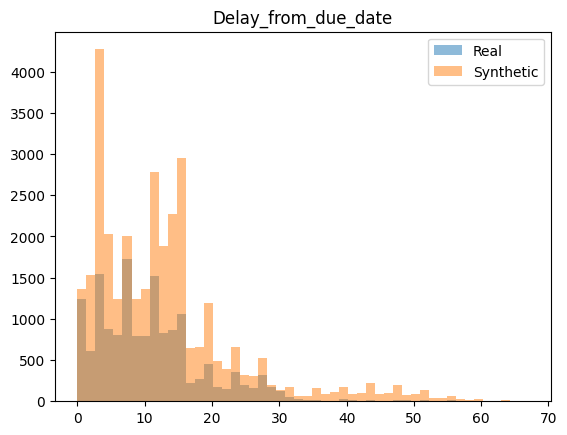


--- Num_of_Delayed_Payment ---
Real Mean: 24.70 | Synthetic Mean: 30.51
Real Std:  212.80 | Synthetic Std:  222.49


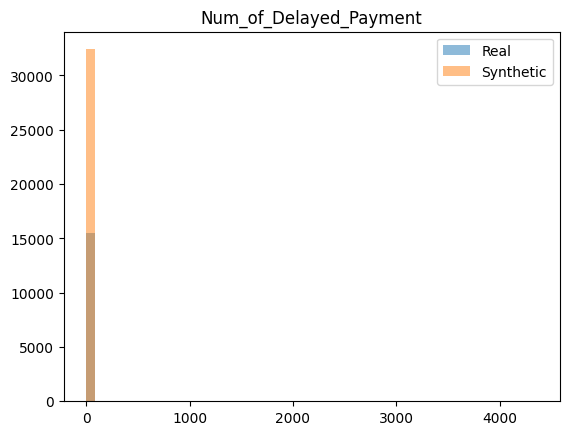


--- Changed_Credit_Limit ---
Real Mean: 7.17 | Synthetic Mean: 8.72
Real Std:  4.56 | Synthetic Std:  5.94


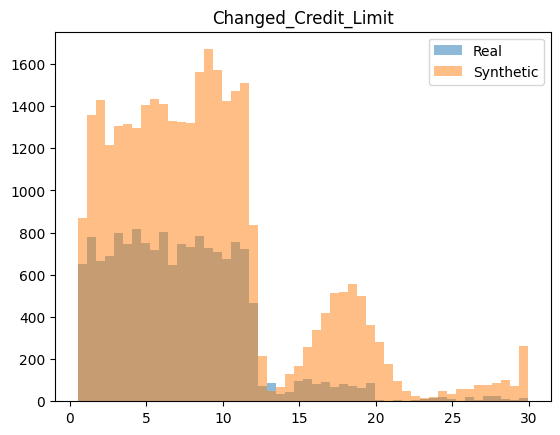


--- Num_Credit_Inquiries ---
Real Mean: 3.18 | Synthetic Mean: 3.42
Real Std:  2.46 | Synthetic Std:  3.23


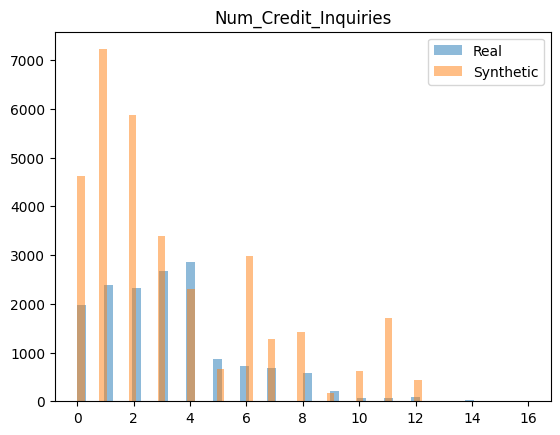


--- Outstanding_Debt ---
Real Mean: 803.55 | Synthetic Mean: 1040.23
Real Std:  615.88 | Synthetic Std:  1056.23


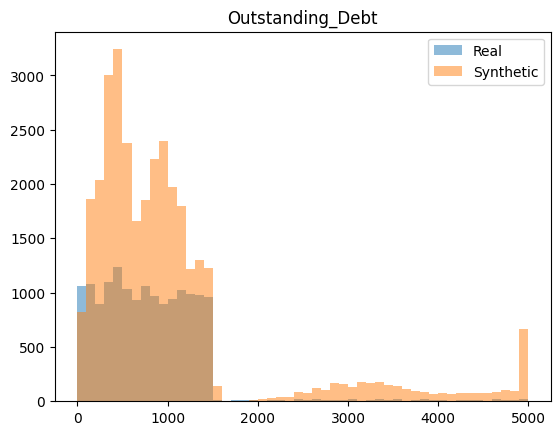


--- Credit_Utilization_Ratio ---
Real Mean: 32.53 | Synthetic Mean: 33.89
Real Std:  5.14 | Synthetic Std:  5.54


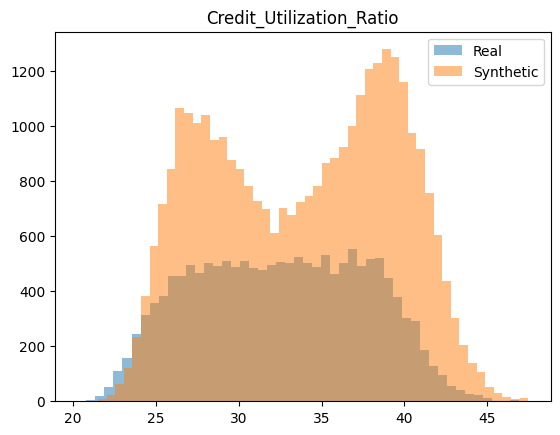


--- Amount_invested_monthly ---
Real Mean: 198.36 | Synthetic Mean: 189.26
Real Std:  134.74 | Synthetic Std:  138.20


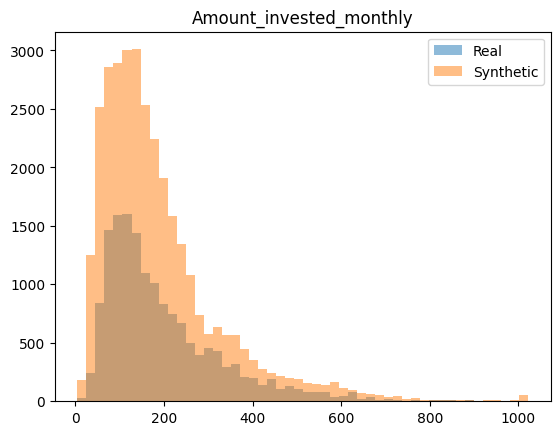


--- Monthly_Balance ---
Real Mean: 456.41 | Synthetic Mean: 460.74
Real Std:  220.21 | Synthetic Std:  219.62


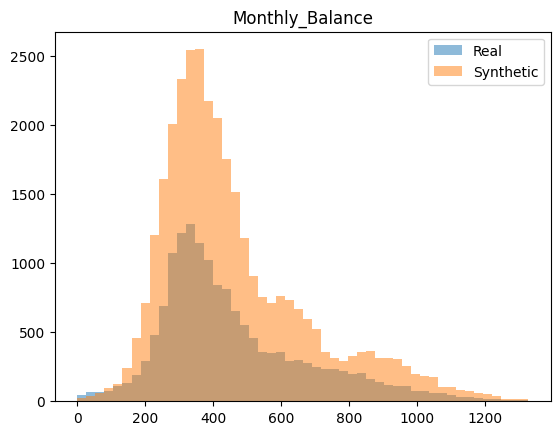


--- Credit_History_Years ---
Real Mean: 23.22 | Synthetic Mean: 21.04
Real Std:  6.15 | Synthetic Std:  8.14


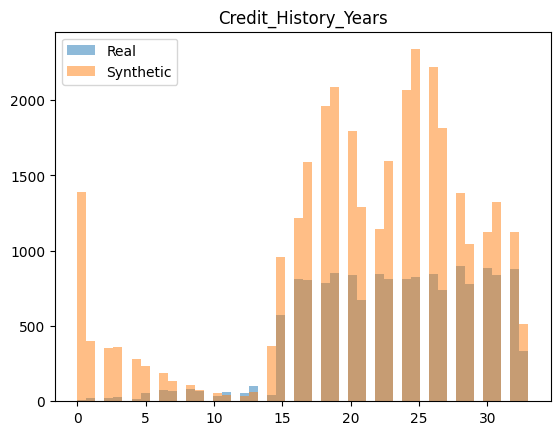


CATEGORICAL COLUMN ANALYSIS

--- Occupation ---
                   Real  Synthetic
Occupation                        
Accountant     0.066328   0.087273
Architect      0.068640   0.095780
Developer      0.066457   0.092628
Doctor         0.066072   0.077267
Engineer       0.070952   0.064139
Entrepreneur   0.064595   0.043269
Journalist     0.070053   0.055754
Lawyer         0.070887   0.055938
Manager        0.069539   0.065883
Mechanic       0.062283   0.057560
Media_Manager  0.071529   0.069341
Musician       0.065558   0.057805
Scientist      0.066007   0.049879
Teacher        0.071144   0.068576
Writer         0.049955   0.058906


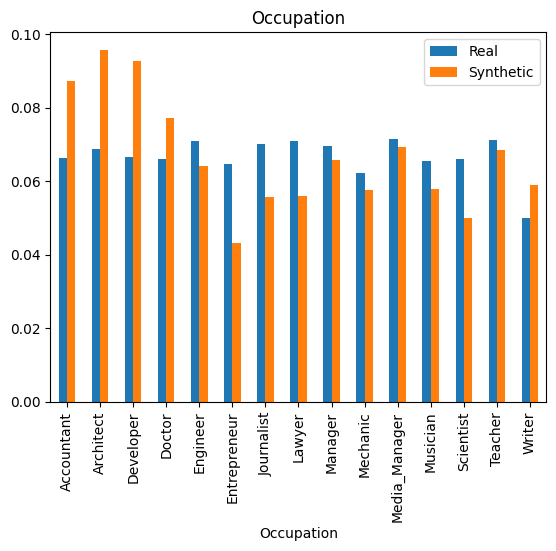


--- Credit_Mix ---
                Real  Synthetic
Credit_Mix                     
Good        0.823552   0.720034
Standard    0.156415   0.201842
Bad         0.020033   0.078124


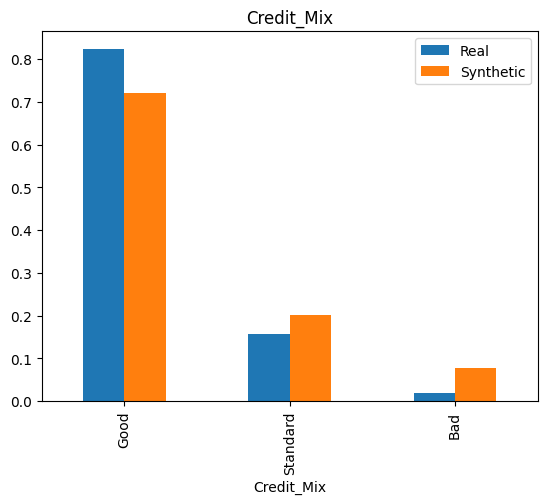


--- Payment_of_Min_Amount ---
                           Real  Synthetic
Payment_of_Min_Amount                     
NM                     0.126557   0.213348
No                     0.760819   0.568622
Yes                    0.112624   0.218030


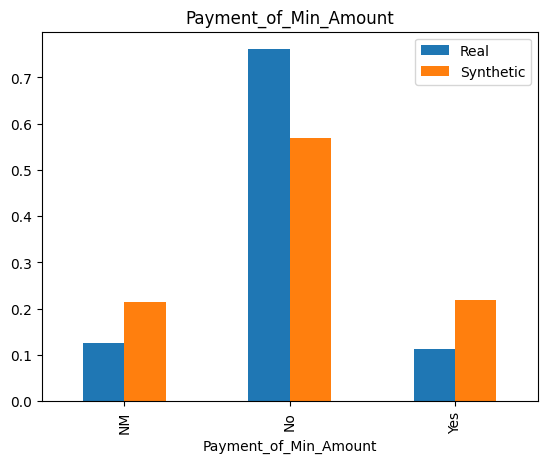


--- Credit_Score ---
              Real  Synthetic
Credit_Score                 
Good           1.0        1.0


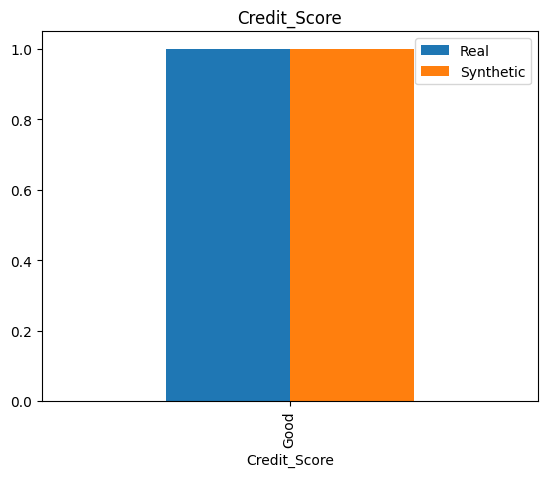


--- Spending_Level ---
                    Real  Synthetic
Spending_Level                     
High            0.490690   0.411763
Low             0.431874   0.461397
Missing         0.077437   0.126840


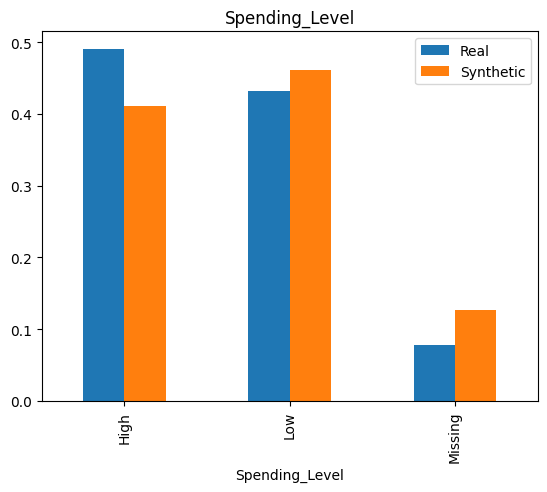


--- Payment_Size ---
                  Real  Synthetic
Payment_Size                     
Large         0.280018   0.247162
Medium        0.335495   0.254016
Missing       0.077437   0.135286
Small         0.307050   0.363536


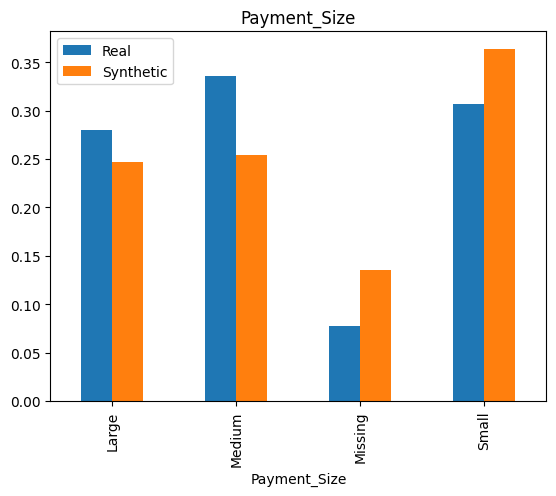

In [17]:
columns = [
    "Age","Occupation","Annual_Income","Monthly_Inhand_Salary",
    "Num_Bank_Accounts","Num_Credit_Card","Interest_Rate",
    "Num_of_Loan","Delay_from_due_date","Num_of_Delayed_Payment",
    "Changed_Credit_Limit","Num_Credit_Inquiries","Credit_Mix",
    "Outstanding_Debt","Credit_Utilization_Ratio",
    "Payment_of_Min_Amount","Amount_invested_monthly",
    "Monthly_Balance","Credit_Score","Credit_History_Years",
    "Spending_Level","Payment_Size"
]

compare_datasets(real=df_good, synthetic=synthetic_good, columns=columns)